## SECTION 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

## SECTION 2 — Load Dataset

In [2]:
#LOAD DATA
from google.colab import drive
drive.mount('/content/drive')

FILE_PATH = "/content/drive/MyDrive/Colab_Notebooks/SLT_PROJECT/5000.csv"
df = pd.read_csv(FILE_PATH)

Mounted at /content/drive


In [3]:
df.head()

,CALL_TIME,lang,mainOption,subOption,IVRPosition,existingFault,suspendedAsset,dataLimitExceed,extraGBAdded,validAccount,outstanding,selectedQueue,enteredQueue,isAnswered,queue_time,talk_time,total_time
0,5/13/2026 23:59,S,14.0,NaN,S7,NaN,NaN,NaN,NaN,True,6467.85,S7,YES,YES,273,85,447
1,5/13/2026 23:59,S,4.0,extragb,S4112,NaN,NaN,NaN,NaN,True,2979.45,S41,NaN,NaN,0,0,60
2,5/13/2026 23:59,S,1.0,NaN,S1,NaN,NaN,NaN,NaN,True,-84.53,S1,YES,YES,225,172,480
3,5/13/2026 23:59,S,1.0,NaN,SLty1,NaN,NaN,NaN,NaN,False,NaN,S1,YES,NaN,0,0,129
4,5/13/2026 23:59,S,NaN,NaN,S,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,0,0,74


## SECTION 3 — Understand Dataset

In [5]:
print(df.shape)

(5000, 17)


In [6]:
print(df.columns)

Index(['CALL_TIME', 'lang', 'mainOption', 'subOption', 'IVRPosition',
       'existingFault', 'suspendedAsset', 'dataLimitExceed', 'extraGBAdded',
       'validAccount', 'outstanding', 'selectedQueue', 'enteredQueue',
       'isAnswered', 'queue_time', 'talk_time', 'total_time'],
      dtype='object')


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CALL_TIME        5000 non-null   object 
 1   lang             4604 non-null   object 
 2   mainOption       3563 non-null   float64
 3   subOption        2400 non-null   object 
 4   IVRPosition      4604 non-null   object 
 5   existingFault    131 non-null    object 
 6   suspendedAsset   645 non-null    object 
 7   dataLimitExceed  51 non-null     object 
 8   extraGBAdded     279 non-null    object 
 9   validAccount     4994 non-null   object 
 10  outstanding      3388 non-null   float64
 11  selectedQueue    3572 non-null   object 
 12  enteredQueue     2713 non-null   object 
 13  isAnswered       787 non-null    object 
 14  queue_time       5000 non-null   int64  
 15  talk_time        5000 non-null   int64  
 16  total_time       5000 non-null   int64  
dtypes: float64(2),

In [8]:
df.describe()

,mainOption,outstanding,queue_time,talk_time,total_time
count,3563.000000,3.388000e+03,5000.000000,5000.000000,5000.000000
mean,3.636542,1.118705e+04,117.094600,19.227200,328.673800
std,3.571218,2.145526e+05,290.487126,62.461667,367.628622
min,1.000000,-1.250000e+04,0.000000,0.000000,0.000000
25%,2.000000,3.349000e+01,0.000000,0.000000,39.000000
50%,2.000000,3.486560e+03,0.000000,0.000000,157.000000
75%,4.000000,6.374560e+03,0.000000,0.000000,519.000000
max,14.000000,1.156483e+07,1655.000000,868.000000,2296.000000


## SECTION 4 — Missing Values

In [9]:
df.isnull().sum()

,0
CALL_TIME,0
lang,396
mainOption,1437
subOption,2600
IVRPosition,396
existingFault,4869
suspendedAsset,4355
dataLimitExceed,4949
extraGBAdded,4721
validAccount,6


In [10]:
drop_cols = [
    'existingFault',
    'suspendedAsset',
    'dataLimitExceed',
    'extraGBAdded'
]

df.drop(columns=drop_cols, inplace=True)

In [11]:
df.isnull().sum()

,0
CALL_TIME,0
lang,396
mainOption,1437
subOption,2600
IVRPosition,396
validAccount,6
outstanding,1612
selectedQueue,1428
enteredQueue,2287
isAnswered,4213


In [12]:
df['isAnswered'].value_counts(dropna=False)

,count
isAnswered,
NaN,4213
YES,787


In [13]:
df['isAnswered'].fillna('NO', inplace=True)

/tmp/ipykernel_12606/3289277157.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['isAnswered'].fillna('NO', inplace=True)


In [15]:
df.head()

,CALL_TIME,lang,mainOption,subOption,IVRPosition,validAccount,outstanding,selectedQueue,enteredQueue,isAnswered,queue_time,talk_time,total_time
0,5/13/2026 23:59,S,14.0,NaN,S7,True,6467.85,S7,YES,YES,273,85,447
1,5/13/2026 23:59,S,4.0,extragb,S4112,True,2979.45,S41,NaN,NO,0,0,60
2,5/13/2026 23:59,S,1.0,NaN,S1,True,-84.53,S1,YES,YES,225,172,480
3,5/13/2026 23:59,S,1.0,NaN,SLty1,False,NaN,S1,YES,NO,0,0,129
4,5/13/2026 23:59,S,NaN,NaN,S,False,NaN,NaN,NaN,NO,0,0,74


In [16]:
df.isnull().sum()

,0
CALL_TIME,0
lang,396
mainOption,1437
subOption,2600
IVRPosition,396
validAccount,6
outstanding,1612
selectedQueue,1428
enteredQueue,2287
isAnswered,0


In [17]:
# lang → 396 missing
df['lang'].fillna(df['lang'].mode()[0], inplace=True)
# mainOption → 1437 missing
df['mainOption'].fillna('Unknown', inplace=True)
# subOption → 2600 missing
df['subOption'].fillna('None', inplace=True)
# IVRPosition → 396 missing
df['IVRPosition'].fillna(df['IVRPosition'].mode()[0], inplace=True)
# validAccount → 6 missing
df['validAccount'].fillna(df['validAccount'].mode()[0], inplace=True)
# outstanding → 1612 missing
df['outstanding'].fillna(df['outstanding'].median(), inplace=True)
# selectedQueue → 1428 missing
df['selectedQueue'].fillna('NoQueue', inplace=True)
# enteredQueue → 2287 missing
df['enteredQueue'].fillna('NO', inplace=True)

/tmp/ipykernel_12606/2453250152.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['lang'].fillna(df['lang'].mode()[0], inplace=True)
/tmp/ipykernel_12606/2453250152.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

In [18]:
df.isnull().sum()

,0
CALL_TIME,0
lang,0
mainOption,0
subOption,0
IVRPosition,0
validAccount,0
outstanding,0
selectedQueue,0
enteredQueue,0
isAnswered,0


In [19]:
df.head()

,CALL_TIME,lang,mainOption,subOption,IVRPosition,validAccount,outstanding,selectedQueue,enteredQueue,isAnswered,queue_time,talk_time,total_time
0,5/13/2026 23:59,S,14.0,None,S7,True,6467.85,S7,YES,YES,273,85,447
1,5/13/2026 23:59,S,4.0,extragb,S4112,True,2979.45,S41,NO,NO,0,0,60
2,5/13/2026 23:59,S,1.0,None,S1,True,-84.53,S1,YES,YES,225,172,480
3,5/13/2026 23:59,S,1.0,None,SLty1,False,3486.56,S1,YES,NO,0,0,129
4,5/13/2026 23:59,S,Unknown,None,S,False,3486.56,NoQueue,NO,NO,0,0,74


In [20]:
df.tail()

,CALL_TIME,lang,mainOption,subOption,IVRPosition,validAccount,outstanding,selectedQueue,enteredQueue,isAnswered,queue_time,talk_time,total_time
4995,5/13/2026 21:44,S,3.0,None,S3,True,22439.85,S3,NO,NO,0,0,43
4996,5/13/2026 21:44,S,2.0,peotv,S21,True,633.32,S2,YES,NO,0,0,626
4997,5/13/2026 21:44,S,Unknown,None,S,False,3486.56,NoQueue,NO,NO,0,0,76
4998,5/13/2026 21:44,S,2.0,peotv,S21,True,5284.56,S2,NO,NO,0,0,52
4999,5/13/2026 21:44,S,1.0,None,S1,True,5026.76,S1,YES,NO,0,0,486


## SECTION 5 — Target Understanding

In [21]:
df['isAnswered'].value_counts()

,count
isAnswered,
NO,4213
YES,787


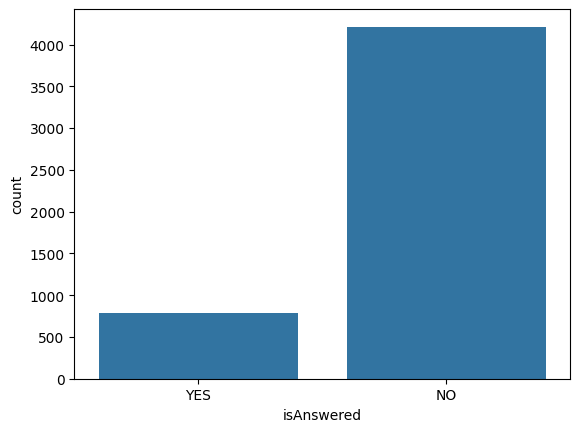

In [22]:
sns.countplot(x='isAnswered', data=df)
plt.show()

## SECTION 6 — Exploratory Data Analysis (EDA)

In [23]:
# Language vs Answered
pd.crosstab(df['lang'], df['isAnswered'])

isAnswered,NO,YES
lang,,
E,137,38
S,3978,725
T,98,24


In [24]:
# Queue vs Answered
pd.crosstab(df['selectedQueue'], df['isAnswered'])

isAnswered,NO,YES
selectedQueue,,
E1,10,6
E2,32,21
E3,19,4
E41,31,1
E52,0,1
E7,10,4
ECS,5,1
E_LTY,0,1
ING_SINHALA,4,0


In [25]:
# Average Queue Time
df.groupby('selectedQueue')['queue_time'].mean()

,queue_time
selectedQueue,
E1,96.812500
E2,191.830189
E3,111.608696
E41,19.281250
E52,266.000000
E7,138.142857
ECS,41.166667
E_LTY,173.000000
ING_SINHALA,0.000000


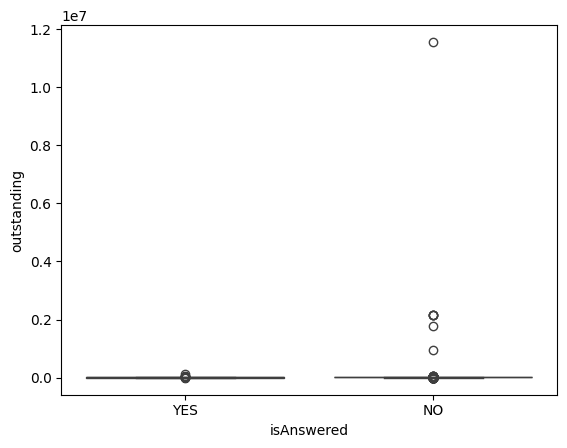

In [26]:
# Outstanding vs Answered
sns.boxplot(x='isAnswered', y='outstanding', data=df)
plt.show()

## SECTION 7 — Correlation Heatmap

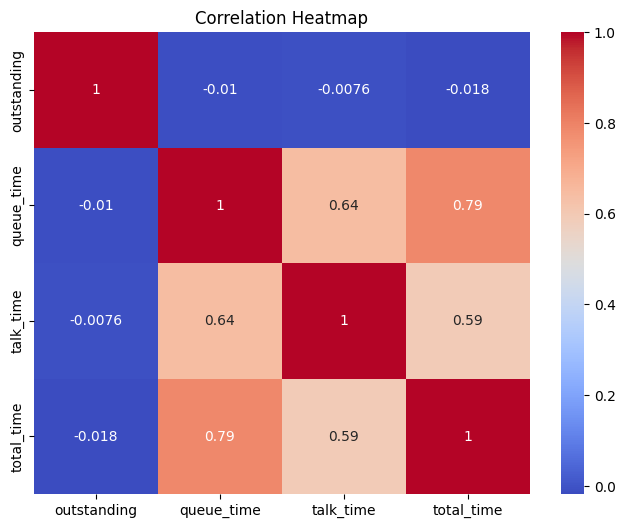

In [27]:
num_cols = ['outstanding', 'queue_time', 'talk_time', 'total_time']

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## SECTION 8 — Data Preprocessing

In [31]:
le = LabelEncoder()

cat_cols = ['lang', 'mainOption', 'selectedQueue', 'enteredQueue', 'isAnswered']

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

## SECTION 9 — Feature Selection

In [32]:
features = [
    'lang',
    'mainOption',
    'outstanding',
    'selectedQueue',
    'queue_time',
    'talk_time',
    'total_time',
    'isAnswered'
]

## SECTION 10 — Scaling

In [35]:
scaler = StandardScaler()

for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    if df[col].isnull().any():
        df[col].fillna(df[col].mode()[0], inplace=True)

X_scaled = scaler.fit_transform(df[features])

## SECTION 11 — SUBCLU / PROCLUS

In [36]:
# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = [
    'lang',
    'mainOption',
    'subOption',
    'IVRPosition',
    'validAccount',
    'selectedQueue',
    'enteredQueue',
    'isAnswered'
]

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print(df.head())

         CALL_TIME  lang  mainOption  subOption  IVRPosition  validAccount  \
0  5/13/2026 23:59     1           2          1           80             1   
1  5/13/2026 23:59     1           5          4           64             1   
2  5/13/2026 23:59     1           0          1           47             1   
3  5/13/2026 23:59     1           0          1           81             0   
4  5/13/2026 23:59     1           8          1           46             0   

   outstanding  selectedQueue  enteredQueue  isAnswered  queue_time  \
0      6467.85              2             1           1         273   
1      2979.45             22             0           0           0   
2       -84.53             12             1           1         225   
3      3486.56             12             1           0           0   
4      3486.56             19             0           0           0   

   talk_time  total_time  
0         85         447  
1          0          60  
2        172         48

In [37]:
# Select features
features = [
    'lang',
    'mainOption',
    'subOption',
    'validAccount',
    'outstanding',
    'selectedQueue',
    'enteredQueue',
    'isAnswered',
    'queue_time',
    'talk_time',
    'total_time'
]

X = df[features]

In [38]:
# Scale the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [39]:
# Convert back to DataFrame
import pandas as pd

X_scaled = pd.DataFrame(X_scaled, columns=features)

X_scaled.head()

,lang,mainOption,subOption,validAccount,outstanding,selectedQueue,enteredQueue,isAnswered,queue_time,talk_time,total_time
0,0.043534,-1.055406,-0.862345,0.687887,-0.012663,-2.899876,0.918138,2.313707,0.536757,1.053116,0.321896
1,0.043534,0.181108,0.184614,0.687887,-0.032413,0.749052,-1.089160,-0.432207,-0.403138,-0.307855,-0.730902
2,0.043534,-1.879749,-0.862345,0.687887,-0.049761,-1.075412,0.918138,2.313707,0.371501,2.446110,0.411669
3,0.043534,-1.879749,-0.862345,-1.453728,-0.029542,-1.075412,0.918138,-0.432207,-0.403138,-0.307855,-0.543194
4,0.043534,1.417622,-0.862345,-1.453728,-0.029542,0.201713,-1.089160,-0.432207,-0.403138,-0.307855,-0.692817


In [40]:
# First clustering attempt (DBSCAN)
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.8, min_samples=5)

labels = dbscan.fit_predict(X_scaled)

df['Cluster'] = labels

print(df['Cluster'].value_counts())

Cluster
 2     1273
 13    1029
 0      646
 3      378
 8      289
-1      244
 7      209
 12      96
 1       96
 9       75
 19      72
 14      69
 15      66
 21      60
 4       51
 5       43
 11      34
 17      32
 10      29
 27      21
 20      19
 32      16
 18      13
 34      11
 29      11
 26      10
 24      10
 23       9
 22       8
 36       7
 16       7
 39       7
 30       7
 6        6
 25       6
 37       6
 31       6
 40       5
 28       5
 33       5
 41       5
 35       5
 38       4
Name: count, dtype: int64


In [41]:
# Understand clusters
df.groupby('Cluster')[[
    'queue_time',
    'talk_time',
    'total_time',
    'outstanding'
]].mean()

,queue_time,talk_time,total_time,outstanding
Cluster,,,,
-1,427.016393,151.516393,740.049180,98754.589590
0,0.000000,0.000000,69.902477,6089.189288
1,0.000000,0.000000,329.947917,3486.560000
2,0.000000,0.000000,52.270228,3486.560000
3,810.687831,93.285714,987.613757,3496.624630
4,0.000000,0.000000,42.549020,3486.560000
5,0.000000,0.000000,140.348837,3919.355814
6,237.500000,75.166667,395.666667,7594.030000
7,0.000000,0.000000,420.153110,4328.054976


In [42]:
# Crosstab
pd.crosstab(df['Cluster'], df['isAnswered'])

isAnswered,0,1
Cluster,,
-1,69,175
0,646,0
1,96,0
2,1273,0
3,0,378
4,51,0
5,43,0
6,0,6
7,209,0
